In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
data_path = Path('/content/drive/MyDrive/Colab Notebooks/NotebookData')

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

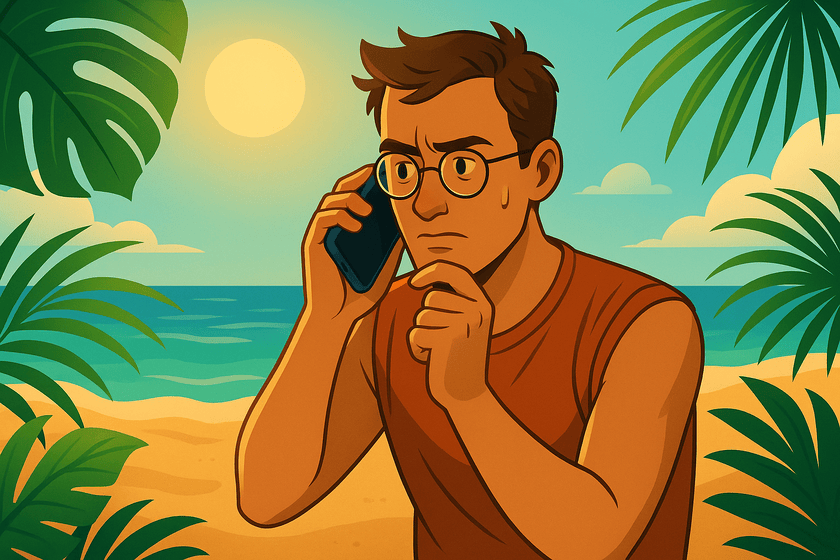

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [3]:
titanic_df = pd.read_csv(data_path / 'titanic.csv', index_col='PassengerId')
titanic_df.describe(include='all') # Sprawdzam aktualne wartości - ilości i średnie
# Widać że nie każdy ma uzupełniony wiek, cenę biletum, numer kabiny oraz port

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,793.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,33.123938,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,51.578312,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.925000,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.500000,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN


Przy spojrzeniu na plik widać również, że kolumny $PassengerId$ oraz $Ticket$ nie mają za dużego znaczenia, ponieważ zarówno id jak i numer biletu nie jest w żaden sposób powiazany z osobą czy też z tym czy przeżył uderzenie w lodowiec. W związku z tym usuwamy te dwie kolumny. Kolumny $Age$, $Fare$, $Cabin$ oraz $Embarked$ musimy uzupełnić zrobimy to w następujący sposób:
- $Age$ wyciągniemy tytuł (który będzie osobną kategorią) każdego pasażera: Mr,Ms, Master (np. Master to jest dziecko więc nie możemy mu przypisać 30 lat) itd. i zgodnie z nim przypiszemy odpowiedni z pomocą mediany
- $Fare$ możemy wziąć średnią z danej klasy biletu (I, II, III)
- $Cabin$ uzupełnimy wpisując $Unknown$ lub $Unsigned$, nie miał. Z uwagi na ogromne braki w danych możnaby było zastanowić się nad wykasowaniem całej kolumny, póki co zostawiam
- $Embarked$ to jedynie 2 brakujące dane zatem użyjemy dominanty

In [4]:
titanic_df.dtypes # Sprawdzam typy danych, aby zmienić nieodpowiednie

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [5]:
titanic_df.drop(columns=['PassengerId', 'Ticket'], inplace=True, errors='ignore') #inplace sprawia że nie kopiujemy nie potrzebnie danych i wszystko dzieje się bezpośrednio na obiekcie zamiast na jego kopii

In [6]:
titanic_df['Title'] = titanic_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False) # expand = False, po to żebyśmy mieli listę nie nową tabelę 'r' jest po to żeby Python nie nadintepretowywał escape sequenców
print(titanic_df['Title'].value_counts()) # Widzimy tutaj że niektóre tytuły występują bardzo rzadko lub pojedynczo wrzucamy to do kolumny Rare aby nie wpadać w klątwe wielowymiarowości
titanic_df['Title'] = titanic_df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
titanic_df['Title'] = titanic_df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}) #Mile, Ms to to samo co Miss, a Mme to samo co Mrs

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [7]:
titanic_df['Age'] = titanic_df['Age'].fillna(
    titanic_df.groupby('Title')['Age'].transform('median') # Uzupełniam według mediany z danego tytułu
)

Widzimy, że:
- $Sex$ dla ułatwienia pracy modelu lepiej zamienić typ object (string) na kodowanie 0 - kobieta, 1 - mężczyzna
- $Embarked$ też możemy zmapować za pomocą One Hot Encoding możemy stworzyć sobie prosty wektor tego kto gdzie wsiadł [0,0,1] - gdzie 1 oznacza miejsce wejścia na pokład
- $Pclass$ tak samo jak w $Embarked$ użyjemy One Hot Encoding'u
- $Title$ podobnie jak w przypadku $Pclass$ i $Embarked$ używamy One Hot Encoding'u

In [8]:
titanic_df['Sex'] = titanic_df['Sex'].map({'female' : 0, 'male' : 1}).astype('int32') # Ustawiamy naszą płeć jako zmienną binarną tak/nie ponieważ to jest tylko 0/1 robimy int'a 32 bitowego żeby oszczędzać pamięć
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknown') # Używamm fillna bez wcześniejszego dodania kategorii bo Cabin jest typu object
titanic_df['Fare'] = titanic_df['Fare'].fillna(
    titanic_df.groupby('Pclass')['Fare'].transform('median') # Uzupełniam według mediany z danej klasy
)
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0]) # Uzupełniam miejsce wejścia na pokład za pomocą mody
titanic_df = pd.get_dummies (
    data=titanic_df,
    prefix = ['Embarked', 'Pclass', 'Title'],
    columns = ['Embarked', 'Pclass', 'Title'],
    dtype=np.int32 # Dla oszczędnośći pamięci używamy inta 32 bitowego
) # Robimy encoding na wyżej wymienionych zmiennych
titanic_df.drop(columns=['Name'], inplace=True) # Skoro nie używamy już imion a reszte informacji kodujemy na inne sposoby możemy się pozbyć naszej kolumny Imię i Nazwisko, inplace znowu, żęby nie marnować zasobów

In [9]:
titanic_df['Cabin'].str[0].unique()

array(['U', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

Sugerując się tą częścią stworzymy kolejną zmienną określającą miejsce znajdowania się na statku, ponieważ kolumna Cabin jest dość dziurawa (pełno w niej uzupełnionych $Unknown$) uzupełniamy według wyżej wymienionej tablicy + $U$ jako Unknown. Zakodojuemy to znowu za pomocą One Hot Coding'u możemy być jednak zagrożeni przez overfitting przy modelach ale tutaj czyszczę tylko dane.


In [19]:
titanic_df['Location'] = titanic_df['Cabin'].str[0]
titanic_df = pd.get_dummies (
    data=titanic_df,
    prefix = 'Location',
    columns = ['Location'],
    dtype=np.int32 # Dla oszczędnośći pamięci używamy inta 32 bitowego
) # Robimy encoding na wyżej wymienionych zmiennych
titanic_df.drop(columns=['Cabin'], inplace=True) # Kolumna Cabin staje się już dla nas zbędna

#Przejdźmy do wizualizacji
Najpierw importujemy biblioteki do wizualizacji danych.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

### Związek między płcią a przeżyciem
Wykres jasno pokazuje, że większość mężczyzn zmarło w wyniku wypadku najpewniej ratując kobiety.

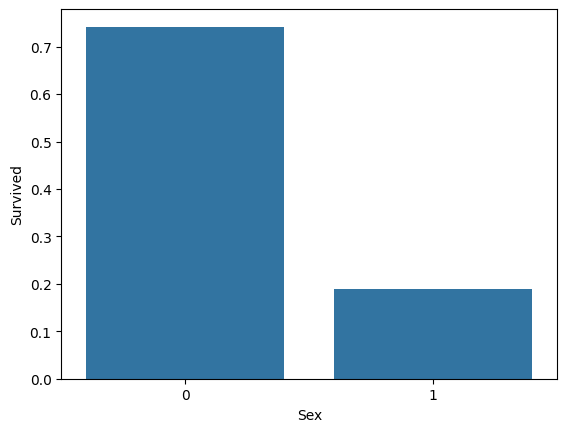

In [12]:
sns.barplot(data=titanic_df, x='Sex', y='Survived', errorbar=None) #errorbar none to bład pomiarowy nie pokazujemy go bo nasze dane nie posiadają go
plt.show()

### Zależność między wiekiem a przeżyciem
Wykres przedstawia kto przeżył, a komu się nie udało względem wieku.

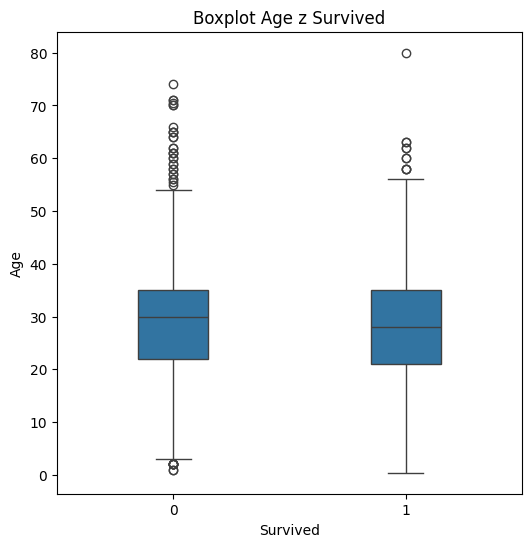

In [13]:
def drawBoxPlot(data_frame, column_1, column_2=None):
  plt.figure(figsize=(6,6))
  if column_2 is None: # Jeżeli wykres ma tylko jedną kolumnę w wywołaniu funkcji robimy inny typ wykresu
      sns.boxplot(data=data_frame, y=column_1, width=0.3)
      plt.title(f"Boxplot: {column_1}")
  else: # Jeżeli ma dwie robimy inny
    sns.boxplot(data=data_frame, y = column_1, x = column_2, width=0.3)
    plt.title(f"Boxplot {column_1} z {column_2}")
  plt.show()
drawBoxPlot(titanic_df, 'Age', 'Survived') # Wywołanie dla porównania wieku z współczynnikiem przeżywalności

### Wykres prezdstawiający koszty biletu
Jasno widać, że większość osób þłynących zapłaciło stosunkowo mało za swoje bilety. Wykres wskazuje, że drogie bielty to outlinery.

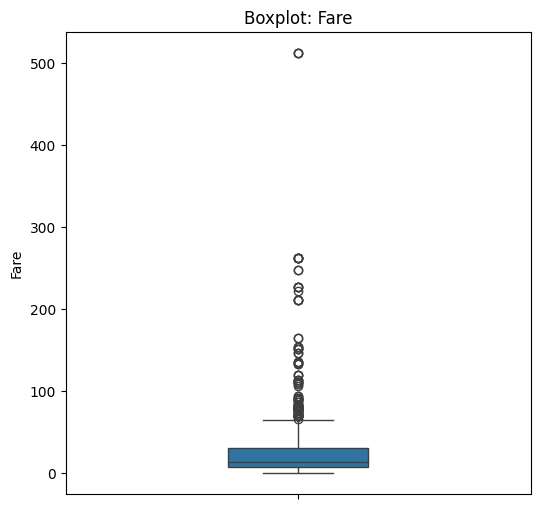

In [14]:
drawBoxPlot(titanic_df, 'Fare', ) # Wykres przedstawiający koszty biletów

### Wykres pokazujący korelację między opłatą za bilet a klasą w jakiej pasażer się znajdował
Wykres ukazuje oczywistą oczywistość. Najdroższe bilety były pierwaszej klasy, klasy trzeciej najtańsze, a klasy drugiej plasowały się mniej więcej pomiędzy.

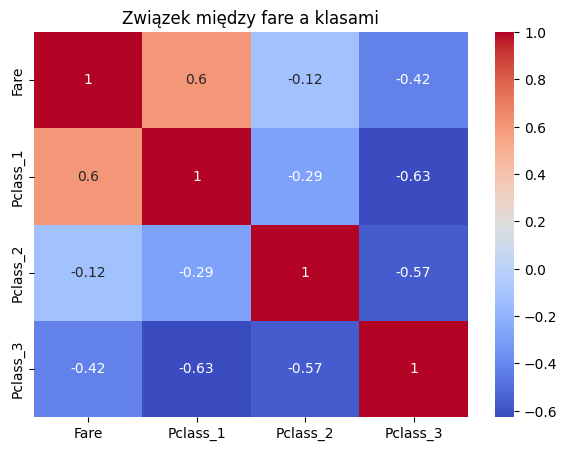

In [15]:
columns = ['Fare', 'Pclass_1', 'Pclass_2', 'Pclass_3']

plt.figure(figsize=(7, 5))
sns.heatmap(
    titanic_df[columns].corr(),
    annot=True,
    cmap='coolwarm',
)
plt.title('Związek między fare a klasami')
plt.show() # Heatmapa przedstawiająca korelację kosztów biletu i klasy biletu

### Wykres przedstawiający związek międzzy przeżywalnością a lokalizacją na statku
Z wykresu widać że największe szanse na przeżycie mialy osoby znajdujące się w częściach  B, D oraz E. Z kolei z części T nie przeżył nikt.

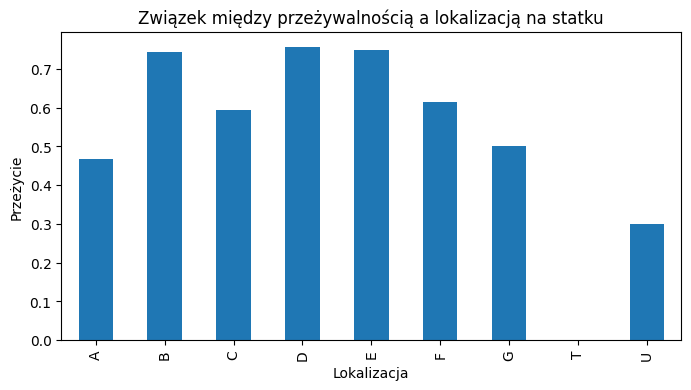

In [18]:
columns = [c for c in titanic_df.columns if c.startswith('Location_')] # List comprehension do wrzucenia odpowiednich kolumn do wykresu
means = {}
for col in columns:
    location = col.replace('Location_', '')
    means[location] = titanic_df[titanic_df[col] == True]['Survived'].mean()
plt.figure(figsize=(8, 4))
pd.Series(means).plot(kind='bar')
plt.title('Związek między przeżywalnością a lokalizacją na statku')
plt.ylabel('Przeżycie (%)')
plt.xlabel('Lokalizacja')
plt.show()